# Olink NPX analysis

**Olink** is an affinity-proteomics platform (Proximity Extension Assay) reporting **NPX** — Normalized Protein eXpression, an arbitrary log2 scale. It powers the largest population proteomics resources (UK Biobank PPP, deCODE). `ov.protein` handles Olink data through:

- `read_olink_npx` — long-format NPX CSV/TSV → `AnnData`
- `normalize(..., log2=False)` — NPX is already log-scale, so only centring is applied
- `de(..., method='welch_t' | 'wilcoxon' | 'olink_lmer')` — group comparison

The statistical engine is the standalone `pyolinkanalyze` package (a port of CRAN OlinkAnalyze).

In [1]:
import omicverse as ov
import numpy as np
import matplotlib.pyplot as plt

ov.plot_set()

/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/scratch/users/steorra/env/omicdev/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
🚫 No GPU devices found (CUDA/MPS/ROCm/XPU)

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.2.0   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.



## 1. Load NPX data

For a real Olink export use the reader — it pivots the long NPX table to samples × proteins:

```python
adata = ov.protein.read_olink_npx('olink_npx.csv')
```

Here we simulate an Olink-style dataset with `platform='olink'` — NPX-scale values, no MNAR dropouts, a typical ~90-protein inflammation panel.

In [2]:
adata = ov.protein.simulate_lfq(n_proteins=92, n_per_group=20,
                                platform='olink', seed=0)
print(adata)
print('NPX range:', round(float(adata.X.min()), 1), '..', round(float(adata.X.max()), 1))

AnnData object with n_obs × n_vars = 40 × 92
    obs: 'group'
    var: 'Gene_names', 'is_de_true'
    uns: 'source'
NPX range: -5.7 .. 5.0


## 2. Normalization

NPX is already log2 — pass `log2=False` so `normalize` only median-centres each sample (correcting plate / loading offsets) without re-logging.

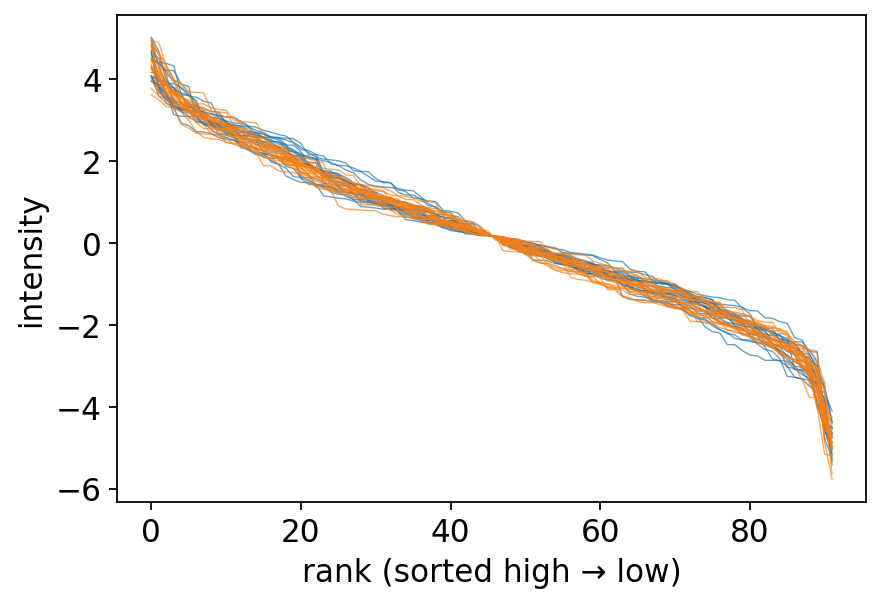

In [3]:
ov.protein.normalize(adata, method='median', log2=False)
ov.protein.abundance_rank_plot(adata, log=False, color_by='group')
plt.show()

## 3. Differential expression

Olink panels are small (≤ a few thousand proteins) and rarely have missing values, so per-protein tests are the norm. `welch_t` and `wilcoxon` both work directly; `olink_lmer` adds a linear mixed model for paired / repeated-measures designs (`subject_var=`).

In [4]:
res_t = ov.protein.de(adata, group='group', method='welch_t')
res_w = ov.protein.de(adata, group='group', method='wilcoxon')
print('welch_t  significant (adj.P < 0.05):', int((res_t['adj.P.Val'] < 0.05).sum()))
print('wilcoxon significant (adj.P < 0.05):', int((res_w['adj.P.Val'] < 0.05).sum()))

welch_t  significant (adj.P < 0.05): 8
wilcoxon significant (adj.P < 0.05): 8


In [5]:
res_t.head()

,gene,logFC,AveExpr,t,P.Value,adj.P.Val
0,prot_0070,1.112051,0.664083,10.611274,6.436036e-13,5.921154e-11
1,prot_0025,-1.008370,-0.440152,-7.697879,4.174653e-09,1.920340e-07
2,prot_0059,1.043387,-0.744543,6.425293,1.864498e-07,5.717793e-06
3,prot_0057,-1.172297,0.783944,-6.231449,3.068180e-07,7.056815e-06
4,prot_0035,-1.207765,0.269082,-5.578741,2.865369e-06,4.593771e-05


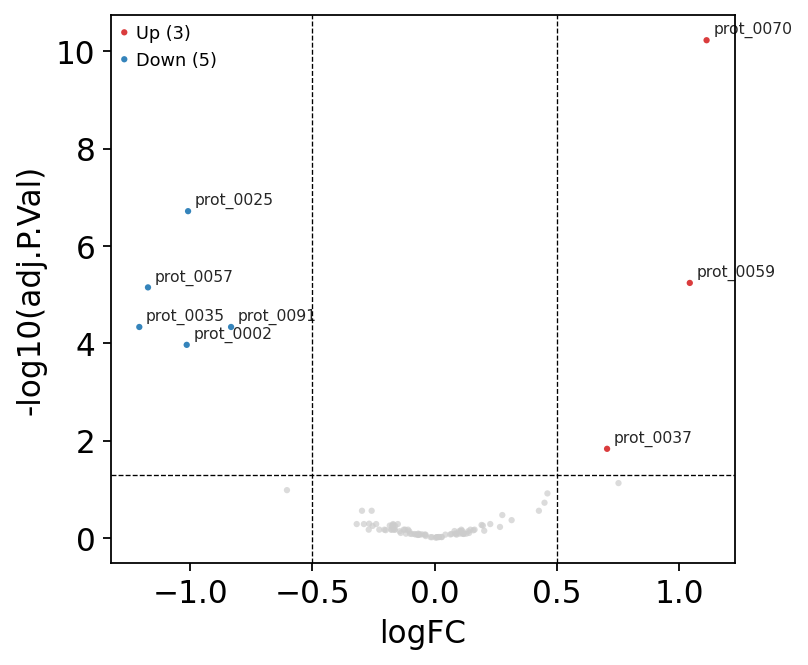

In [6]:
ov.protein.volcano(res_t, fc_col='logFC', p_col='adj.P.Val',
                   logfc_threshold=0.5, adj_p_threshold=0.05)
plt.show()

## Summary

Olink NPX flows through the same `ov.protein` API as LC-MS/MS — the only differences are `read_olink_npx` for I/O and `log2=False` at the normalize step (NPX is pre-logged). For bridge normalization across Olink batches, plate randomization, ANOVA, and pathway enrichment, use the standalone `pyolinkanalyze` package directly. See [the bulk intro tutorial](t_protein_01_intro.ipynb) for the full pipeline reference.